# Simple Bot 

1. Define `state` structure with a list of `HumanMessage` objects.
2. Initialize a **local LLM** using `LangChain's ChatOpenAI` pointed to **LM Studio**.
3. Sending and handling different types of messages.
4. Building and compiling the graph of the `Agent`.


## **Main Goal: How to integrate `LLMs` in our Graphs**

---

## Graph Diagram

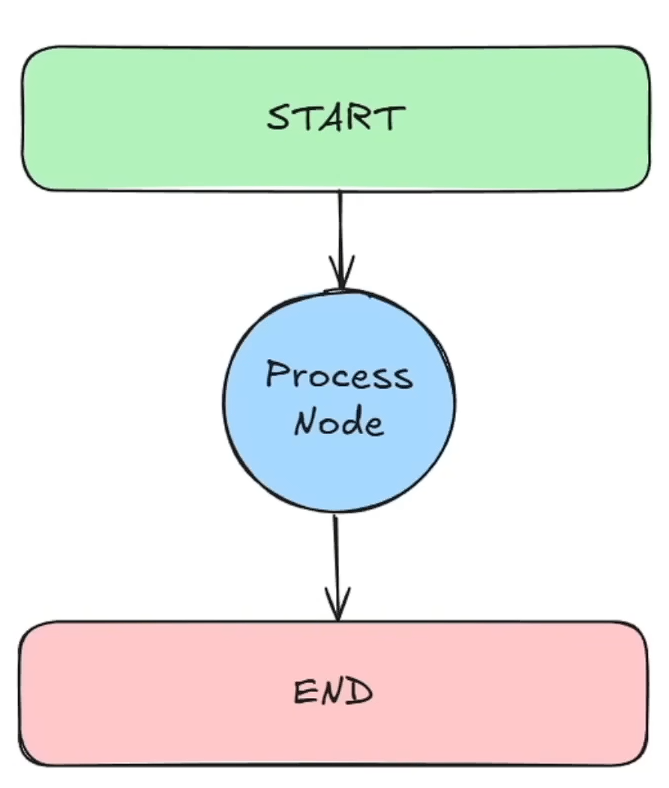

---

#### 1. Import Libraries

In [ ]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict): 
    messages : List[HumanMessage]

#### 2. Initialize the LLM

Although we use `ChatOpenAI`, setting `base_url` to point to **LM Studio** means all requests go to your **local server** — not to OpenAI's servers. The class is just an HTTP client that speaks the OpenAI API format, which LM Studio supports.

In [ ]:
# 100% local - connects to LM Studio, not OpenAI
llm = ChatOpenAI(
    base_url="http://localhost:1234/v1",
    api_key="lm-studio",  # LM Studio doesn't validate this, any string works
    model="local-model"   # LM Studio ignores this, uses whatever model you have loaded
)

In [ ]:
def process(state: AgentState) -> AgentState:
    """
    Process the input for the LLM
    """
    response = llm.invoke(state["messages"])
    print(f" {response.content}")

    return state

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.add_edge(START, "process")
graph.add_edge("process", END)
agent = graph.compile()

In [ ]:
user_input = input("Enter: ")
while user_input != "exit":
    agent.invoke({"messages" : [HumanMessage(content= user_input)]})
    user_input = input("Enter: ")
